In [134]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from utils import get_eval_stats
import scipy

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [135]:
target_protein=None
test_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/"
valid_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/validation/"
summary_func = np.mean

In [136]:
#################################

drakes_df = pd.read_csv(test_dir + "drakes_test.csv")
pretrained_df = pd.read_csv(test_dir + "pretrained_test.csv")

drakes_eval_stats = get_eval_stats(drakes_df, target_protein=target_protein, summary_func=summary_func)
pre_eval_stats = get_eval_stats(pretrained_df, target_protein=target_protein, summary_func=summary_func)

drakes_ddg_align = drakes_eval_stats['ddg_align']
pre_ddg_align = pre_eval_stats['ddg_align']

#################################

bon10_df = pd.read_csv(test_dir + "target/group1/pretrained_test_ddg_bon_N=10.csv")
bon50_df = pd.read_csv(test_dir + "target/group1/pretrained_test_ddg_bon_N=50.csv")

bon10_eval_stats = get_eval_stats(bon10_df, target_protein=target_protein, summary_func=summary_func)
bon50_eval_stats = get_eval_stats(bon50_df, target_protein=target_protein, summary_func=summary_func)

bon10_ddg_align = bon10_eval_stats['ddg_align']
bon50_ddg_align = bon50_eval_stats['ddg_align']

#################################

In [137]:
spec10_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192.csv")
spec10_rl_df = pd.read_csv(test_dir + "target/group1/" + "drakes_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192.csv")
spec10_bon10_df = pd.read_csv(test_dir + "target/group1/" + f"pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192_rmax=True.csv")

spec10_eval_stats = get_eval_stats(spec10_df, target_protein=target_protein, summary_func=summary_func)
spec10_rl_eval_stats = get_eval_stats(spec10_rl_df, target_protein=target_protein, summary_func=summary_func)
spec10_bon10_eval_stats = get_eval_stats(spec10_bon10_df, target_protein=target_protein, summary_func=summary_func)

In [138]:
neurips_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/neurips/"

spec20_bon10_df = pd.read_csv(neurips_dir + f"pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=True_.csv")
spec20_rl_df = pd.read_csv(neurips_dir + f"drakes_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=False_.csv")
spec20_df = pd.read_csv(test_dir + 'new/' + 'pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=32768_rmax=False_.csv')


spec20_bon10_eval_stats = get_eval_stats(spec20_bon10_df, target_protein=target_protein, summary_func=summary_func)
spec20_eval_stats = get_eval_stats(spec20_df, target_protein=target_protein, summary_func=summary_func)
spec20_rl_eval_stats = get_eval_stats(spec20_rl_df, target_protein=target_protein, summary_func=summary_func)



In [139]:
ex10_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=10.csv")
ex10_bon10_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=10.csv")

In [140]:
exclusion_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=10.csv")
# gradient_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=gradient_maxspecorder=10.csv")
# hill_climb_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=hill-climb_maxspecorder=10_hcits=8192.csv")
# max_mask_df = pd.read_csv(test_dir + "target/group1/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=10_masks=8192.csv")


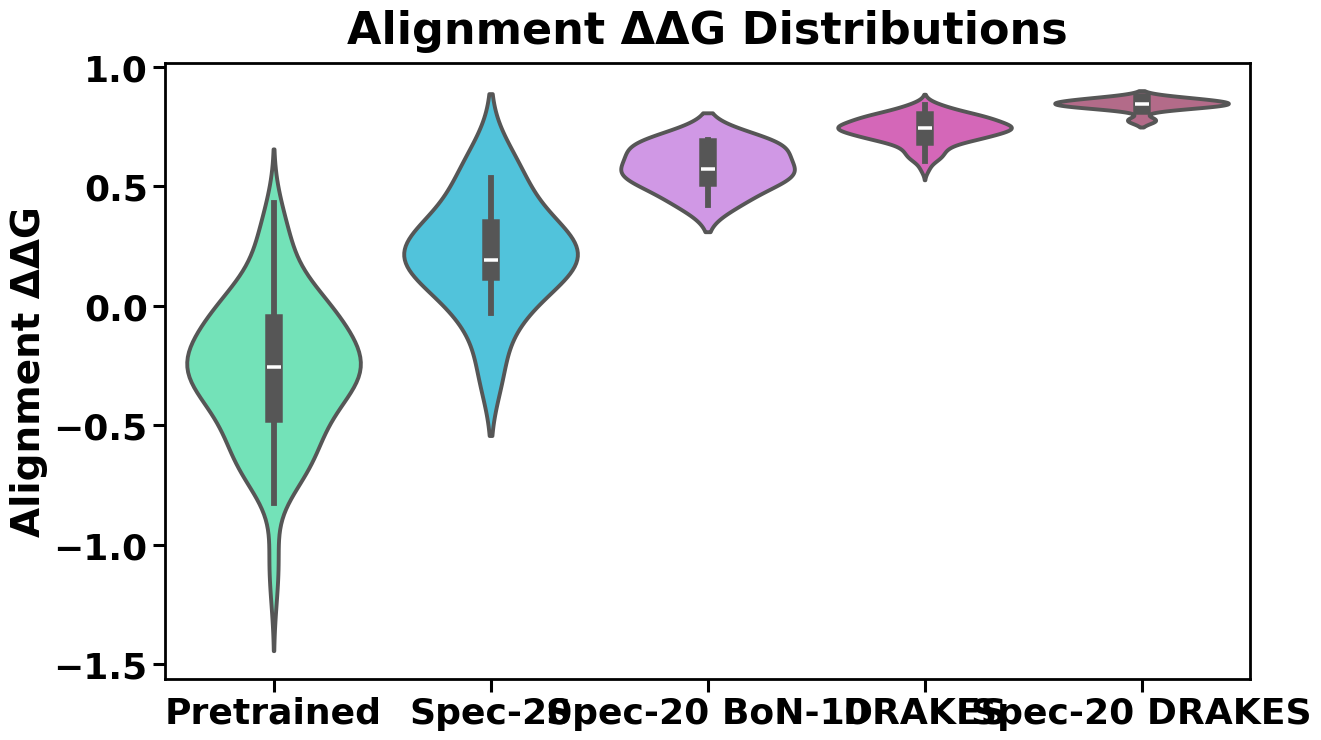

In [141]:
# Assuming you have already defined dfs, names, and colors
dfs = [pretrained_df, spec20_df, spec20_bon10_df, drakes_df, spec20_rl_df]
names = ['Pretrained', 'Spec-20', 'Spec-20 BoN-10', 'DRAKES', 'Spec-20 DRAKES']
colors = ["#61F4BC", "#3AD2F2", "#D68BF2", "#E655C1", "#BF5F87"]

# dfs_filtered, names, colors = zip(*reversed(list(zip(dfs, names, colors))))

dfs_filtered = [
    df[df['protein_name'] == 'HEEH_KT_rd6_0746.pdb'] for df in dfs
]

# Prepare the data by concatenating the filtered DataFrames
df_combined = pd.concat([df[['ddg']].assign(Experiment=name) for df, name in zip(dfs_filtered, names)])

FS_TITLE, FS_AXIS, FS_TICK = 32, 28, 26

# Create a violin plot (large typography for small in-paper width)
plt.figure(figsize=(14, 8))
ax = sns.violinplot(x='Experiment', y='ddg', data=df_combined, palette=colors, legend=False, hue='Experiment', linewidth=2.8)

plt.title(f'Alignment ΔΔG Distributions', fontsize=FS_TITLE, fontweight='bold', pad=14)
xlabel_angle = 0
plt.xlabel('')
plt.xticks(rotation=xlabel_angle)
plt.ylabel('Alignment ΔΔG', fontsize=FS_AXIS, fontweight='bold')
ax.tick_params(axis='both', labelsize=FS_TICK, width=2.2, length=9)
for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    label.set_fontweight('semibold')
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
plt.show()


Saved PDF to: /home/shai/NeuripsProtein2026/Figures/ddg_align_overlap_baseline_spec20.pdf


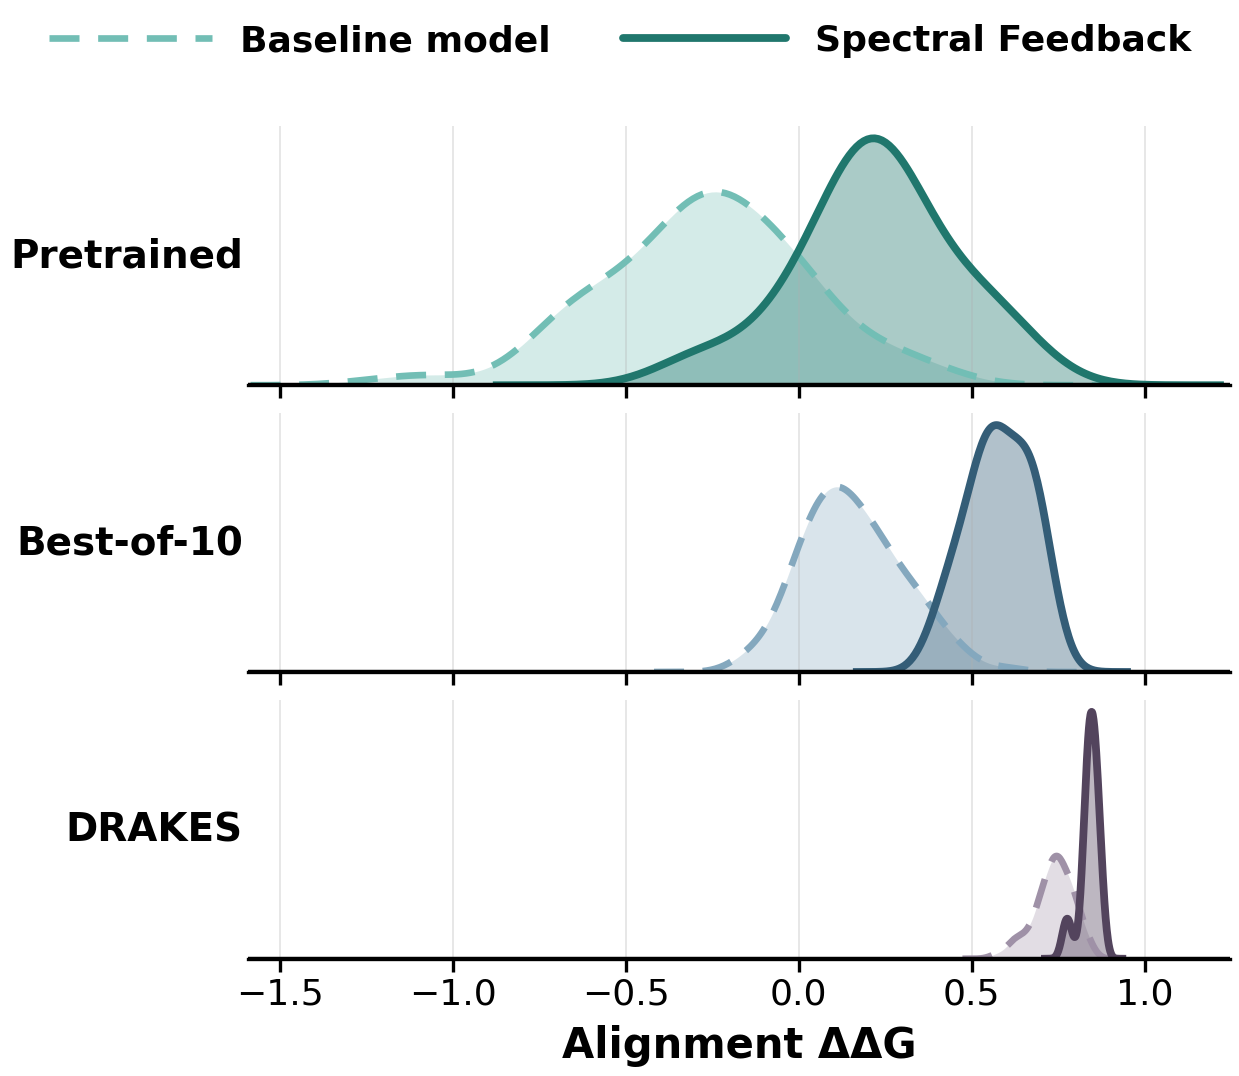

In [142]:
#################################
# Horizontal distribution overlaps (base vs SPEC-20)

import numpy as np
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb

# Typography / stroke sizes for readability at ~1/3 manuscript column width (~2× prior sizes)
FS_ROW = 28
FS_AXIS = 30
FS_TICK = 26
FS_LEGEND = 26
LW_KDE_LIGHT = 4.8
LW_KDE_BOLD = 5.6
LW_AXLINE = 3.2
LW_SPINE = 2.4

protein_name = 'HEEH_KT_rd6_0746.pdb'

def _vals(df):
    return df.loc[df['protein_name'] == protein_name, 'ddg'].dropna().to_numpy()

def _lighten(color, amount=0.22):
    r, g, b = to_rgb(color)
    # Blend toward white by `amount` for a natural lighter partner shade.
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

def _darken(color, amount=0.20):
    r, g, b = to_rgb(color)
    return (r * (1 - amount), g * (1 - amount), b * (1 - amount))

# Row hue anchors; baseline is paler, SPEC-20 is deliberately darkened (fill + opaque outline).
base_colors = {
    'Pretrained': '#2A9D8F',
    'Best-of-10': '#457B9D',
    'DRAKES': '#6D597A',
}

# (row label, base df, spec20 df)
rows = [
    ('Pretrained', pretrained_df, spec20_df),
    ('Best-of-10', bon10_df, spec20_bon10_df),
    ('DRAKES', drakes_df, spec20_rl_df),
]

# Legend swatches (Pretrained row); each panel uses its own light/dark pair for dashes vs solid.
_leg_baseline_c = _lighten(base_colors['Pretrained'], amount=0.34)
_leg_spectral_c = _darken(base_colors['Pretrained'], amount=0.24)

# Shared x-range with padding so KDE tails can fall to ~0 before the axis ends (sharex otherwise clips wide).
_chunks = [_vals(bd) for _, bd, _ in rows] + [_vals(sd) for _, _, sd in rows]
_all_x = np.concatenate([c for c in _chunks if len(c) > 0])
_xlo, _xhi = float(np.min(_all_x)), float(np.max(_all_x))
_xpad = max(0.18 * (_xhi - _xlo), 0.12)
_xlim_shared = (_xlo - _xpad, _xhi + _xpad)
_kde_cut = 4.5

fig, axes = plt.subplots(nrows=len(rows), ncols=1, figsize=(12.5, 10.0), sharex=True)

for ax, (label, base_df, spec_df) in zip(axes, rows):
    base = _vals(base_df)
    spec = _vals(spec_df)
    row_hue = base_colors[label]
    # Baseline: light fill + dashed outline in the same light shade. SPEC-20: filled + solid dark outline.
    baseline_c = _lighten(row_hue, amount=0.34)
    spectral_c = _darken(row_hue, amount=0.24)

    # Use cut>0 so KDE tails smoothly taper to (approximately) zero density.
    sns.kdeplot(
        x=base,
        ax=ax,
        color=baseline_c,
        fill=True,
        alpha=0.30,
        linewidth=0,
        bw_adjust=1.0,
        cut=_kde_cut,
    )
    sns.kdeplot(
        x=base,
        ax=ax,
        color=baseline_c,
        fill=False,
        linewidth=LW_KDE_LIGHT,
        linestyle=(0, (4.5, 2.8)),
        bw_adjust=1.0,
        cut=_kde_cut,
    )
    sns.kdeplot(
        x=spec,
        ax=ax,
        color=spectral_c,
        fill=True,
        alpha=0.38,
        linewidth=0,
        bw_adjust=1.0,
        cut=_kde_cut,
    )
    sns.kdeplot(
        x=spec,
        ax=ax,
        color=spectral_c,
        fill=False,
        linewidth=LW_KDE_BOLD,
        linestyle='-',
        bw_adjust=1.0,
        cut=_kde_cut,
    )

    ax.axhline(0, color='black', linewidth=LW_AXLINE)
    ax.set_ylim(bottom=0)
    ax.margins(y=0)
    ax.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=FS_ROW, fontweight='bold')
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_linewidth(LW_SPINE)
    ax.grid(axis='x', alpha=0.32, linewidth=1.35)
    ax.tick_params(axis='x', labelsize=FS_TICK, width=LW_SPINE, length=9)

for ax in np.atleast_1d(axes):
    ax.set_xlim(_xlim_shared)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=_leg_baseline_c,
        linewidth=LW_KDE_LIGHT,
        linestyle=(0, (4.5, 2.8)),
        label='Baseline model',
        solid_capstyle='round',
    ),
    Line2D(
        [0],
        [0],
        color=_leg_spectral_c,
        linewidth=LW_KDE_BOLD,
        linestyle='-',
        label='Spectral Feedback',
        solid_capstyle='round',
    ),
]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.09),
    prop={'size': FS_LEGEND, 'weight': 'bold'},
    handlelength=4.5,
)

axes[-1].set_xlabel('Alignment ΔΔG', fontsize=FS_AXIS, fontweight='bold', labelpad=10)
# fig.suptitle('Alignment ΔΔG Dist (base vs SPEC-20)', fontsize=15, y=1.10)
fig.tight_layout(rect=[0, 0, 1, 0.97])
from pathlib import Path
_pdf_path = Path('/home/shai/NeuripsProtein2026/Figures') / 'ddg_align_overlap_baseline_spec20.pdf'
_pdf_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_pdf_path, format='pdf', bbox_inches='tight', pad_inches=0.12)
print(f'Saved PDF to: {_pdf_path}')
plt.show()

#################################
